In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
file = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Eye Irritation\dataset\train_set_eye_irritation_features_rdkitcdk.sdf"

sdfInfo = dict(smilesName='SMILES', molColName='ROMol')
moldf = PandasTools.LoadSDF(file, **sdfInfo)
print(moldf.shape)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf.drop_duplicates(subset=['SMILES'])
moldf = moldf[pd.notnull(moldf['Mol'])]

print(moldf.shape)
moldf.keys()


(1828, 65)
(1828, 65)


Index(['Outcome', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3', 'Mol'],
      dtype='object')

In [3]:
moldf

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0858958172735298, -1.372566035884163, -1.3...",1608,CC(O)CO,76.052429496,-0.6405000000000001,31.057602761014792,40.46,...,3.0,4.0,0.3333333333333333,1.0,0.0,40.46,3.0,-0.748,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002207A6...
1,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5078503976983185, 0.05839121285330338, 0.10...",617,CCCCCCCCCCCC[N+](C)(C)CCCS(=O)(=O)O,336.2566914960899,4.261600000000003,138.17676602501464,54.370000000000005,...,12.0,18.0,0.4705882352941176,15.0,2.0,62.75,5.392317422778761,5.019999999999998,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002207A6...
2,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.47515459257872156, 0.39000886268962404, 0....",13,CCC1(CO)COCOC1,146.094294308,0.3794,60.94439677188973,38.69,...,2.0,2.0,0.4,2.0,0.0,38.69,4.321928094887363,0.2439999999999999,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002207A6...
3,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5364250449069771, -1.0993449477973771, -1....",368,C=CCCCCCCCC,140.15650064,3.9230000000000027,65.33412702521478,0.0,...,10.0,10.0,0.4444444444444444,7.0,1.0,0.0,4.169925001442312,5.664,0.8,<rdkit.Chem.rdchem.Mol object at 0x000002207A6...
4,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0111170801950289, -1.1640682089309673, -1....",838,CC(O)CCO,90.06807956,-0.25039999999999996,37.4225448754114,40.46,...,4.0,5.0,0.5,2.0,0.0,40.46,3.321928094887362,-0.39,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002207A6...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1823,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9718916228574594, 0.39553883491703684, 0.45...",1645,OCCCOCC(COCCCO)(COCCCO)COCCCO,368.24101811199995,-0.4311999999999982,150.20944078498687,117.84000000000002,...,3.0,13.0,0.5,20.0,1.0,117.84000000000002,5.584962500721157,-1.75,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002207F2...
1824,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4479577103546899, 0.3332568814599739, 0.39...",1102,O=C(O)c1ccc(O)c(O)c1,154.026608672,0.7959999999999998,62.34056859052537,77.76,...,0.0,3.0,0.5,1.0,0.0,77.76,4.459431618637298,0.986,0.0,<rdkit.Chem.rdchem.Mol object at 0x000002207F2...
1825,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0858958172735298, -1.372566035884162, -1.3...",1137,CCC(C)=O,72.057514876,0.9854,31.995599471063137,17.07,...,4.0,4.0,0.3333333333333333,1.0,0.0,17.07,3.0,0.438,0.75,<rdkit.Chem.rdchem.Mol object at 0x000002207F2...
1826,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.16152685598990882, -0.7174480082943241, -0....",1301,CCCCCCCCCCCCCC(=O)OC,242.2245802,4.8605000000000045,107.12350795893273,26.3,...,14.0,16.0,0.4666666666666667,13.0,2.0,26.3,5.0,6.752999999999998,0.9333333333333332,<rdkit.Chem.rdchem.Mol object at 0x000002207F2...


In [4]:
moldf = moldf.rename(columns={'Outcome': 'Outcome'})

In [5]:
moldf.head(1)

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0858958172735298, -1.372566035884163, -1.3...",1608,CC(O)CO,76.052429496,-0.6405000000000001,31.057602761014792,40.46,...,3.0,4.0,0.3333333333333333,1.0,0.0,40.46,3.0,-0.748,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002207A6...


In [6]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
moldf.head(100)

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0858958172735298, -1.372566035884163, -1.3...",1608,CC(O)CO,76.052429496,-0.6405000000000001,31.057602761014792,40.46,...,3.0,4.0,0.3333333333333333,1.0,0.0,40.46,3.0,-0.748,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002207A6...
1459,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.030244522406833688, 0.6355786907582167, 0.7...",2134,COP(=S)(OC)Oc1cc(Cl)c(I)cc1Cl,411.835355106,4.494100000000002,122.75022171483076,27.69,...,0.0,5.0,0.5,4.0,1.0,69.59,5.0,5.489999999999999,0.25,<rdkit.Chem.rdchem.Mol object at 0x000002207F0...
1458,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.951268316448439, -1.0499930471440644, -1.0...",1602,CO[P+](=O)OC,109.00490710209,0.9365999999999999,37.20932893809189,35.53,...,0.0,5.0,0.5,2.0,0.0,35.53,3.321928094887362,-0.7420000000000001,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002207F0...
1456,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2407228208736663, 0.9356286431485418, 1.01...",2173,C[Si]1(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O1,296.07516536799994,2.8736000000000015,103.25277280587856,36.92,...,0.0,0.0,0.3333333333333333,0.0,0.0,36.92,5.0,4.5600000000000005,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002207F0...
749,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5299624423347523, -0.6051841368109854, -0....",1513,CC(C)=CCCC(C)CCO,156.15141526,2.751300000000001,70.12836077741079,20.23,...,8.0,9.0,0.5,5.0,0.0,20.23,4.321928094887363,3.286,0.8,<rdkit.Chem.rdchem.Mol object at 0x000002207CB...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4717216426613299, 0.03353380012611423, 0.0...",1219,CCC(C)c1ccccc1,134.109550448,3.2001000000000017,62.89117157708339,0.0,...,4.0,4.0,0.5,2.0,0.0,0.0,4.321928094887363,3.996000000000001,0.4,<rdkit.Chem.rdchem.Mol object at 0x000002207DF...
1406,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.609765268089576, -0.020928241732461463, 0....",1302,CCc1cccc(C)c1,120.093900384,2.5574200000000005,56.526229462686786,0.0,...,2.0,2.0,0.4,1.0,0.0,0.0,4.169925001442312,3.36,0.3333333333333333,<rdkit.Chem.rdchem.Mol object at 0x000002207DF...
794,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.07080547351670781, 0.37284411323478117, 0....",1684,C=CCOc1ccc(CC(=O)O)cc1Cl,226.039671892,2.5319000000000003,92.93907796792408,46.53,...,3.0,4.0,0.5,5.0,0.0,46.53,4.906890595608519,2.601,0.1818181818181818,<rdkit.Chem.rdchem.Mol object at 0x000002207CC...
795,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7089222229505214, 0.07259427279942421, -0....",1992,O=C1OCC(CO)O1,118.02660867200001,-0.48590000000000005,46.011092528743674,55.760000000000005,...,0.0,2.0,0.4,1.0,0.0,55.760000000000005,4.0,-0.47,0.75,<rdkit.Chem.rdchem.Mol object at 0x000002207CC...


In [7]:
x_data = moldf.drop(columns=['Outcome','Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP','Mol'])
print(x_data)

               LabuteASA               TPSA                 AMW  \
0     31.057602761014792              40.46              76.095   
1459  122.75022171483076              27.69               413.0   
1458   37.20932893809189              35.53  109.04099999999998   
1456  103.25277280587856              36.92              296.62   
749    70.12836077741079              20.23             156.269   
...                  ...                ...                 ...   
808    58.09199178314606  63.32000000000001             137.138   
807    26.26336900881878              20.23              60.096   
804    99.37961518962989              29.46  226.35999999999996   
815   102.12406210530455               74.6  240.21399999999997   
1827  112.08195475406626              25.36             284.431   

     NumLipinskiHBA NumLipinskiHBD NumRotatableBonds NumHBD NumHBA  \
0                 2              2                 1      2      2   
1459              4              0                 4   

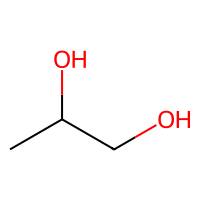

CC(O)CO


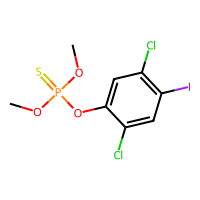

COP(=S)(OC)Oc1cc(Cl)c(I)cc1Cl


In [8]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(df, num_mols):
    for _, row in df.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image

# Assuming 'df' is your DataFrame
# Display the first 10 molecules, each on a new row
display_molecules_in_column(moldf, 2)


Classes                          :  ['0' '1']
Number of cpds in each class     :  [923, 905]
Total number of cpds             :  1828
Class mapping:  {0: 0, 1: 1}


{0: 0, 1: 1}

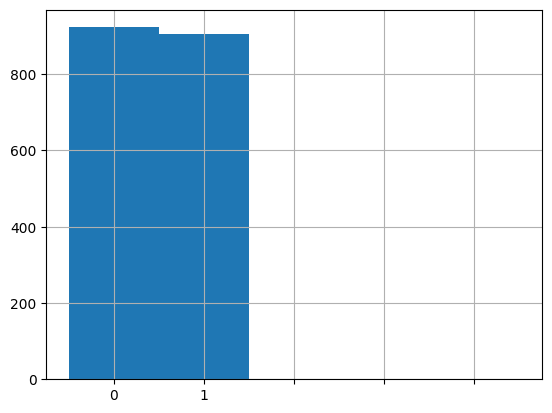

In [11]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(moldf['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y_data = le.transform(moldf['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = moldf['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [12]:
x = x_data
y = y_data

In [14]:
x


,LabuteASA,TPSA,AMW,NumLipinskiHBA,NumLipinskiHBD,NumRotatableBonds,NumHBD,NumHBA,NumAmideBonds,NumHeteroAtoms,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,31.057602761014792,40.46,76.095,2,2,1,2,2,0,2,...,2.0,3.0,4.0,0.3333333333333333,1.0,0.0,40.46,3.0,-0.748,1.0
1459,122.75022171483076,27.69,413.0,4,0,4,0,4,0,8,...,0.0,0.0,5.0,0.5,4.0,1.0,69.59,5.0,5.489999999999999,0.25
1458,37.20932893809189,35.53,109.04099999999998,3,0,2,0,3,0,4,...,0.0,0.0,5.0,0.5,2.0,0.0,35.53,3.321928094887362,-0.7420000000000001,1.0
1456,103.25277280587856,36.92,296.62,4,0,0,0,4,0,8,...,0.0,0.0,0.0,0.3333333333333333,0.0,0.0,36.92,5.0,4.5600000000000005,1.0
749,70.12836077741079,20.23,156.269,1,1,5,1,1,0,1,...,1.0,8.0,9.0,0.5,5.0,0.0,20.23,4.321928094887363,3.286,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
808,58.09199178314606,63.32000000000001,137.138,2,2,1,2,2,0,3,...,2.0,0.0,3.0,0.4,1.0,0.0,63.32000000000001,4.321928094887363,1.249,0.0
807,26.26336900881878,20.23,60.096,1,1,1,1,1,0,1,...,1.0,3.0,4.0,0.3333333333333333,1.0,0.0,20.23,2.584962500721156,0.282,1.0
804,99.37961518962989,29.46,226.35999999999996,2,1,4,1,2,0,2,...,1.0,3.0,5.0,0.5,4.0,0.0,29.46,5.08746284125034,3.1989999999999994,1.0
815,102.12406210530455,74.6,240.21399999999997,4,2,0,2,4,0,4,...,2.0,0.0,0.0,0.4285714285714285,0.0,0.0,74.6,5.321928094887363,2.296,0.0


In [15]:
y

array([0, 0, 0, ..., 1, 1, 1])

In [16]:
#Random Forest
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
# Define your parameter grid as before
paramgrid = {
    "max_features": [
        x.shape[1], x.shape[1] // 2, x.shape[1] // 4, x.shape[1] // 12, x.shape[1] // 10,
        x.shape[1] // 7, x.shape[1] // 5, x.shape[1] // 3
    ],
    "n_estimators": [10, 100, 300, 500],
   
}

# Define the cross-validator as before
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Everything else remains the same in your GridSearchCV initialization and fitting
model_rf_phys = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced'),
                     param_grid=paramgrid,
                     scoring=kappa_scorer,
                     cv=cv,
                     verbose=1,
                     n_jobs=-1)  # Use -1 to use all cores

# Fit the model
model_rf_phys.fit(x, y)
# Get the best model
best_model_rf_phys = model_rf_phys.best_estimator_

print("Best Params:", model_rf_phys.best_params_)
print("Best Score :", model_rf_phys.best_score_)



Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Params: {'max_features': 4, 'n_estimators': 100}
Best Score : 0.37780917147171234


In [19]:
#Random Forest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    # y adalah NumPy array → pakai indexing biasa
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_rf_phys.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_phys.predict(X_test)
    y_proba = best_model_rf_phys.predict_proba(X_test)[:, 1]
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[137  48]
 [ 49 132]]
Confusion Matrix for Fold 2:
[[125  60]
 [ 61 120]]
Confusion Matrix for Fold 3:
[[120  65]
 [ 69 112]]
Confusion Matrix for Fold 4:
[[130  54]
 [ 62 119]]
Confusion Matrix for Fold 5:
[[128  56]
 [ 63 118]]
Overall CV Accuracy: 0.6788831499363724
Overall CV AUC: 0.7407775545182463
Overall CV Precision: 0.6797581105596903
Overall CV Recall (Sensitivity): 0.6640883977900551
Overall CV F1 Score: 0.6717850648508027
Overall CV Specificity: 0.6934077555816687
Overall CV PPV (Positive Predictive Value): 0.6797581105596903
Overall CV NPV (Negative Predictive Value): 0.678152637370886
Overall CV CCR (Correct Classification Rate): 0.678748076685862


In [20]:
#SVM
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Define your parameter grid
paramgrid = {
     "C": [0.1, 1, 10, 50],  # Regularization parameter
     "kernel": ['rbf'],  # Type of the kernel
     "gamma": ['scale', 'auto']  # Kernel coefficient

}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with SVC
model_svm_phys = GridSearchCV(
    estimator=SVC(probability=True),  # probability=True if you need probability estimates
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1  # Use -1 to use all cores
)

# Fit the model
model_svm_phys.fit(x, y)

# Get the best model
best_model_svm_phys = model_svm_phys.best_estimator_

print("Best Params:", model_svm_phys.best_params_)
print("Best Score :", model_svm_phys.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score : 0.26664575722149164


In [26]:
#SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    # y adalah NumPy array → pakai indexing biasa
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_svm_phys.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_phys.predict(X_test)
    y_proba = best_model_svm_phys.predict_proba(X_test)[:, 1]
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[104  81]
 [ 53 128]]
Confusion Matrix for Fold 2:
[[108  77]
 [ 47 134]]
Confusion Matrix for Fold 3:
[[117  68]
 [ 61 120]]
Confusion Matrix for Fold 4:
[[107  77]
 [ 64 117]]
Confusion Matrix for Fold 5:
[[ 83 101]
 [ 50 131]]
Overall CV Accuracy: 0.6285245901639345
Overall CV AUC: 0.698091666612565
Overall CV Precision: 0.6107114219388653
Overall CV Recall (Sensitivity): 0.6961325966850829
Overall CV F1 Score: 0.6497745592898017
Overall CV Specificity: 0.5621974148061104
Overall CV PPV (Positive Predictive Value): 0.6107114219388653
Overall CV NPV (Negative Predictive Value): 0.6532578182056991
Overall CV CCR (Correct Classification Rate): 0.6291650057455966


In [22]:
#XGB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Identify columns with object types
object_cols = x.select_dtypes(include=['object']).columns

# Convert object columns to numeric (if possible) or category
for col in object_cols:
    try:
        x[col] = pd.to_numeric(x[col])
    except ValueError:
        x[col] = x[col].astype('category')

# Define your parameter grid
paramgrid = {
    "max_depth": [3,5,10],  # Common choices for tree depth
    "n_estimators": [100,200,300],  # Number of trees
    "learning_rate": [0.01,0.1]  # Step size shrinkage used to prevent overfitting
}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with XGBClassifier
model_xgb_phys = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),  # use_label_encoder=False and eval_metric='mlogloss' to avoid warnings
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1  # Use -1 to use all cores
)

# Fit the model
model_xgb_phys.fit(x, y)

# Get the best model
best_model_xgb_phys = model_xgb_phys.best_estimator_

print("Best Params:", model_xgb_phys.best_params_)
print("Best Score :", model_xgb_phys.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Score : 0.36464215541563094


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [16:29:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [27]:
#XGB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    # y adalah NumPy array → pakai indexing biasa
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_xgb_phys.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_phys.predict(X_test)
    y_proba = best_model_xgb_phys.predict_proba(X_test)[:, 1]
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [16:36:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [16:36:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [16:36:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, Us

Confusion Matrix for Fold 1:
[[125  60]
 [ 61 120]]
Confusion Matrix for Fold 2:
[[144  41]
 [ 68 113]]
Confusion Matrix for Fold 3:
[[130  55]
 [ 72 109]]
Confusion Matrix for Fold 4:
[[116  68]
 [ 60 121]]
Confusion Matrix for Fold 5:
[[126  58]
 [ 55 126]]
Overall CV Accuracy: 0.6728632382663372
Overall CV AUC: 0.7434624199024871
Overall CV Precision: 0.6780122591363312
Overall CV Recall (Sensitivity): 0.6508287292817678
Overall CV F1 Score: 0.6631591762398316
Overall CV Specificity: 0.694394829612221
Overall CV PPV (Positive Predictive Value): 0.6780122591363312
Overall CV NPV (Negative Predictive Value): 0.6700152311966383
Overall CV CCR (Correct Classification Rate): 0.6726117794469945


In [23]:
# NN 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Pipeline for preprocessing and NN
pipeline_nn = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # Handle NaN values
    ("scaler", StandardScaler()),                   # Scaling is essential for NN
    ("nn", MLPClassifier(
        max_iter=500,
        random_state=42,
        early_stopping=True
    ))
])

# Parameter grid (inspired by RF, SVM, XGB results)
paramgrid = {
    "nn__hidden_layer_sizes": [(256,), (256,128), (512,256,128)],  # moderate-to-deep capacity
    "nn__activation": ["relu"],                                    # nonlinear, consistent with SVM/XGB
    "nn__solver": ["adam"],                                        # adaptive optimizer
    "nn__alpha": [0.0001, 0.001],                                  # regularization strength
    "nn__learning_rate_init": [0.001]                              # stable learning rate
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring function (Cohen's Kappa with quadratic weighting)
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV for NN
model_nn_morgan = GridSearchCV(
    estimator=pipeline_nn,
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit the model
model_nn_morgan.fit(x, y)

# Best model
best_model_nn_morgan = model_nn_morgan.best_estimator_

# Print best parameters and score
print("Best Params:", model_nn_morgan.best_params_)
print("Best Score :", model_nn_morgan.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'nn__activation': 'relu', 'nn__alpha': 0.0001, 'nn__hidden_layer_sizes': (512, 256, 128), 'nn__learning_rate_init': 0.001, 'nn__solver': 'adam'}
Best Score : 0.35261720790844375


In [29]:
#Neural Network NN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    # y adalah NumPy array → pakai indexing biasa
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_nn_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_nn_morgan.predict(X_test)
    y_proba = best_model_nn_morgan.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[106  79]
 [ 50 131]]
Confusion Matrix for Fold 2:
[[130  55]
 [ 76 105]]
Confusion Matrix for Fold 3:
[[130  55]
 [ 63 118]]
Confusion Matrix for Fold 4:
[[110  74]
 [ 38 143]]
Confusion Matrix for Fold 5:
[[108  76]
 [ 42 139]]
Overall CV Accuracy: 0.6674152256905457
Overall CV AUC: 0.7306823301802885
Overall CV Precision: 0.6535276503374398
Overall CV Recall (Sensitivity): 0.7027624309392265
Overall CV F1 Score: 0.67463846739596
Overall CV Specificity: 0.6326321974148061
Overall CV PPV (Positive Predictive Value): 0.6535276503374398
Overall CV NPV (Negative Predictive Value): 0.6894747026858299
Overall CV CCR (Correct Classification Rate): 0.6676973141770164


In [24]:
# LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid inspired by RF, SVM, XGB results
paramgrid = {
    "max_depth": [7, 10],             # moderate to deep trees
    "n_estimators": [100, 300],       # number of boosting iterations
    "learning_rate": [0.05, 0.1],     # step size shrinkage
    "num_leaves": [31, 63],           # leaf complexity
    "min_child_samples": [20, 50]     # minimum data in leaf
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring function (Cohen's Kappa with quadratic weighting)
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV for LightGBM
model_lgbm_morgan = GridSearchCV(
    estimator=LGBMClassifier(verbosity=-1, force_row_wise=True),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit the model
model_lgbm_morgan.fit(x, y)

# Best model
best_model_lgbm_morgan = model_lgbm_morgan.best_estimator_

# Print best parameters and score
print("Best Params:", model_lgbm_morgan.best_params_)
print("Best Score :", model_lgbm_morgan.best_score_)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31}
Best Score : 0.36686682701259354


In [32]:
# Evaluasi LGBM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    # y adalah NumPy array → pakai indexing biasa
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_lgbm_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_lgbm_morgan.predict(X_test)
    y_proba = best_model_lgbm_morgan.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[127  58]
 [ 58 123]]
Confusion Matrix for Fold 2:
[[126  59]
 [ 72 109]]
Confusion Matrix for Fold 3:
[[117  68]
 [ 64 117]]
Confusion Matrix for Fold 4:
[[122  62]
 [ 58 123]]
Confusion Matrix for Fold 5:
[[129  55]
 [ 57 124]]
Overall CV Accuracy: 0.6657728871921551
Overall CV AUC: 0.7352693613623231
Overall CV Precision: 0.6636804524648285
Overall CV Recall (Sensitivity): 0.6585635359116022
Overall CV F1 Score: 0.6609128287171133
Overall CV Specificity: 0.6728260869565218
Overall CV PPV (Positive Predictive Value): 0.6636804524648285
Overall CV NPV (Negative Predictive Value): 0.668117025500736
Overall CV CCR (Correct Classification Rate): 0.6656948114340621


In [33]:
# Save models 

import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Eye Irritation\model\physical chemical properties model"

joblib.dump(
    best_model_rf_phys,
    fr"{base_path}\Model_Eye_RF_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_svm_phys,
    fr"{base_path}\Model_Eye_SVM_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_xgb_phys,
    fr"{base_path}\Model_Eye_XGB_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_nn_morgan,
    fr"{base_path}\Model_Eye_NN_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_lgbm_morgan,
    fr"{base_path}\Model_Eye_LGBM_phys.pkl",
    compress=9
)


['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Eye Irritation\\model\\physical chemical properties model\\Model_Eye_LGBM_phys.pkl']